### # Notebook 03 -- Figures 4, 5, 6: SDF Diagnostics

**Data:** `Results/cluster_month_panels_K_50/cluster_month_panel_K_50_lambda_1000000.csv`
**Output:** Figure 4 (cumulative return), Figure 5 (SDF loading scatter), Figure 6 (rolling Sharpe)


In [6]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
warnings.filterwarnings("ignore")

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, REPO_ROOT)

from utils.data_utils import (
    load_cluster_panel, load_cluster_ranking, pivot_and_rank,
    save_figure,
)

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         12,
    "axes.labelsize":    13,
    "axes.titlesize":    14,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

SDF_WINDOW = 72
NW_LAG     = 3

RECESSIONS = [("1980-01","1980-07"),("1981-07","1982-11"),
              ("1990-07","1991-03"),("2001-03","2001-11"),
              ("2007-12","2009-06")]

def shade_recessions(ax):
    for s, e in RECESSIONS:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   color="grey", alpha=0.13, linewidth=0)

ranking      = load_cluster_ranking()
df           = load_cluster_panel(K=50, lam=1_000_000)
cr, rank_map = pivot_and_rank(df, lam=1_000_000, ranking_df=ranking)

print(f"Cluster return matrix : {cr.shape[0]} months x {cr.shape[1]} clusters")
print(f"Period                : {cr.index[0]}  ->  {cr.index[-1]}")
print(f"L01 mean: {cr['L01'].mean():.4f}   L50 mean: {cr['L50'].mean():.4f}")

Cluster return matrix : 511 months x 50 clusters
Period                : 1977-01-01 00:00:00  ->  2019-12-01 00:00:00
L01 mean: -0.0192   L50 mean: 0.0159


In [7]:

# Minimum-variance linear SDF estimator (from reference notebook)

def _regularize_cov(Sigma, use_ledoit=True, ridge=1e-6, R_win=None):
    Sigma_reg = Sigma.copy()
    if use_ledoit and (R_win is not None):
        try:
            from sklearn.covariance import LedoitWolf
            lw = LedoitWolf().fit(R_win)
            Sigma_reg = lw.covariance_
        except Exception:
            Sigma_reg = Sigma + ridge * np.eye(Sigma.shape[0])
    else:
        Sigma_reg = Sigma + ridge * np.eye(Sigma.shape[0])
    return 0.5 * (Sigma_reg + Sigma_reg.T)


def compute_minvar_sdf_coeffs(mu, Sigma_reg):
    # Solve m = a + b*R (minimum-variance SDF pricing gross returns)
    mu   = np.asarray(mu).reshape(-1, 1)
    N    = mu.shape[0]
    iota = np.ones((N, 1))
    try:
        invS = np.linalg.inv(Sigma_reg)
    except np.linalg.LinAlgError:
        invS = np.linalg.pinv(Sigma_reg)

    muT_invS_mu   = float(mu.T @ invS @ mu)
    muT_invS_iota = float(mu.T @ invS @ iota)

    if np.isclose(muT_invS_mu, 0.0):
        a_star = 0.0
        b_star = (invS @ iota).flatten()
    else:
        a_star = muT_invS_iota / muT_invS_mu
        b_star = (invS @ (iota - a_star * mu)).flatten()

    return a_star, b_star


def rolling_sdf(test_df, window=72, ridge=1e-6, use_ledoit=True):
    # Rolling minimum-variance SDF.
    # test_df: DataFrame of GROSS returns (1 + excess return), indexed by date.
    dates = list(test_df.index)
    cols  = list(test_df.columns)
    m_history = []

    for i in range(window, len(dates)):
        d        = dates[i]
        R_win_df = test_df.iloc[i - window: i].dropna(how="any")

        if R_win_df.shape[0] < max(12, window // 3):
            yield {"date": d, "a": np.nan,
                   "b": np.full(len(cols), np.nan),
                   "m": np.nan, "Sharpe_win": np.nan,
                   "r_oos": test_df.iloc[i].values}
            continue

        R_win     = R_win_df.values
        mu        = R_win.mean(axis=0)
        Sigma     = np.cov(R_win, rowvar=False, ddof=1)
        Sigma_reg = _regularize_cov(Sigma, use_ledoit=use_ledoit,
                                    ridge=ridge, R_win=R_win)
        a_star, b_star = compute_minvar_sdf_coeffs(mu, Sigma_reg)

        r_oos = test_df.iloc[i].values
        m_t   = a_star + float(np.dot(b_star, r_oos))
        m_history.append(m_t)

        if len(m_history) >= window:
            m_s = pd.Series(m_history[-window:])
            sharpe_win = np.sqrt(12) * (m_s.mean() / m_s.std(ddof=1))
        else:
            sharpe_win = np.nan

        yield {"date": d, "a": float(a_star), "b": b_star,
               "m": float(m_t), "Sharpe_win": sharpe_win,
               "r_oos": r_oos, "names": cols}


def compute_sdf_loadings(R_df, m_series):
    # OLS beta of each portfolio on the SDF series
    rows = []
    for port in R_df.columns:
        y = R_df[port].dropna()
        x = m_series.loc[y.index]
        X = sm.add_constant(x)
        model = sm.OLS(y, X).fit()
        rows.append({"portfolio":   port,
                     "mean_return": y.mean(),
                     "beta_sdf":    model.params.iloc[1]})
    return pd.DataFrame(rows).set_index("portfolio")


def nw_se_mean(x, lag=3):
    x = x - x.mean()
    T = len(x)
    s = np.mean(x * x)
    for l in range(1, lag + 1):
        w = 1 - l / (lag + 1)
        s += 2 * w * np.mean(x[l:] * x[:-l])
    return np.sqrt(s / T)


def compute_rolling_sharpe_with_CI(m_series, window=72, freq=12, nw_lag=3):
    SR_list, upper_CI, lower_CI = [], [], []
    for i in range(window, len(m_series)):
        m_win = m_series.iloc[i - window: i]
        mu    = m_win.mean()
        sigma = m_win.std(ddof=1)
        if sigma == 0:
            SR_list.append(np.nan)
            upper_CI.append(np.nan)
            lower_CI.append(np.nan)
            continue
        SR    = np.sqrt(freq) * mu / sigma
        se_mu = nw_se_mean(m_win.values, lag=nw_lag)
        se_SR = np.sqrt(freq) * se_mu / sigma
        SR_list.append(SR)
        upper_CI.append(SR + 1.96 * se_SR)
        lower_CI.append(SR - 1.96 * se_SR)
    return pd.DataFrame({"Sharpe": SR_list,
                         "CI_upper": upper_CI,
                         "CI_lower": lower_CI},
                        index=m_series.index[window:])


print("SDF functions defined.")


SDF functions defined.


In [8]:
# Run rolling SDF on gross returns
print(f"Running rolling SDF (window={SDF_WINDOW}m, Ledoit-Wolf covariance)...")

cr_gross    = cr + 1.0
results_sdf = list(rolling_sdf(cr_gross, window=SDF_WINDOW, ridge=1e-6, use_ledoit=True))

dates_oos = [r["date"] for r in results_sdf]
m_series  = pd.Series([r["m"] for r in results_sdf],
                      index=pd.to_datetime(dates_oos), name="m_sdf")
b_mat     = np.vstack([r["b"] for r in results_sdf])
b_df      = pd.DataFrame(b_mat, index=pd.to_datetime(dates_oos), columns=cr.columns)
R_df      = cr.loc[m_series.index]   # excess returns aligned to OOS dates

print(f"OOS period : {m_series.index[0].date()}  ->  {m_series.index[-1].date()}")
print(f"OOS months : {m_series.notna().sum()}")
s_clean = m_series.dropna()
sr_ann  = np.sqrt(12) * s_clean.mean() / s_clean.std(ddof=1)
print(f"SDF Sharpe (annualised): {sr_ann:.3f}")

Running rolling SDF (window=72m, Ledoit-Wolf covariance)...
OOS period : 1983-01-01  ->  2019-12-01
OOS months : 439
SDF Sharpe (annualised): 2.942


  Saved → output/figures/Figure4_Cumulative_SDF.{pdf,png}


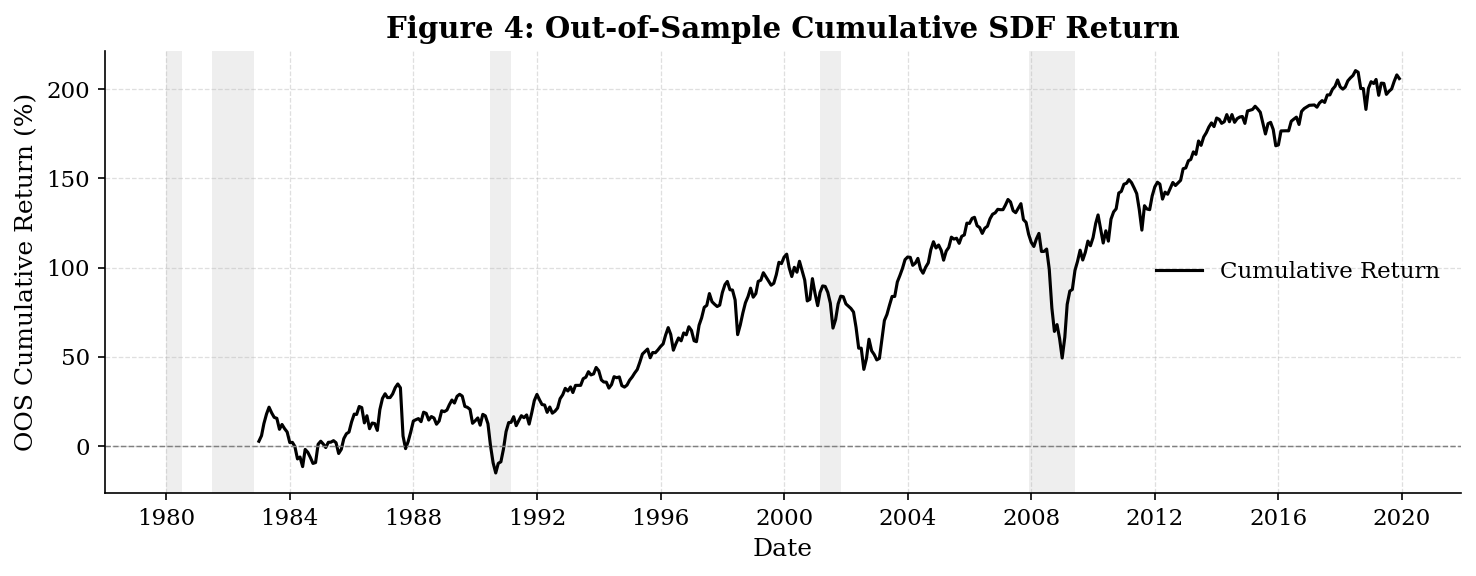

Figure 4 saved.


In [9]:
# Figure 4: Cumulative return (equal-weighted across all 50 clusters)
cum_ret = (R_df.mean(axis=1) * 100).cumsum()

fig4, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_ret.index, cum_ret.values,
        linewidth=1.5, color="black", label="Cumulative Return")
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
shade_recessions(ax)
ax.set_xlabel("Date")
ax.set_ylabel("OOS Cumulative Return (%)")
ax.set_title("Figure 4: Out-of-Sample Cumulative SDF Return", fontweight="bold")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.legend(frameon=False)
plt.tight_layout()
save_figure(fig4, "Figure4_Cumulative_SDF")
plt.show()
print("Figure 4 saved.")

Correlation (mean return vs SDF loading): -0.894  (paper: -0.916)
  Saved → output/figures/Figure5_SDF_Loading_Scatter.{pdf,png}


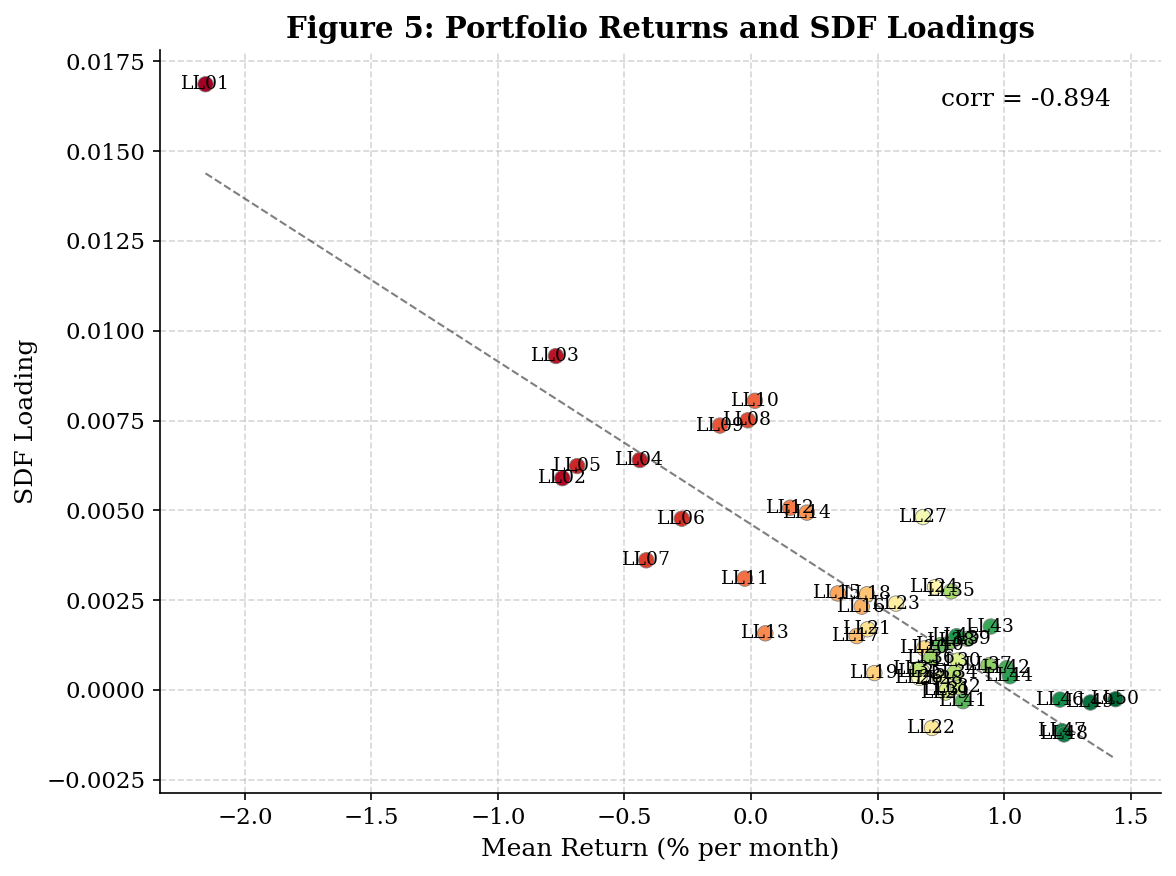

Figure 5 saved.


In [10]:
# Figure 5: Mean return vs SDF loading (OLS beta of portfolio on m_series)
stats_df = compute_sdf_loadings(R_df, m_series)

x    = stats_df["mean_return"] * 100
y    = stats_df["beta_sdf"]
corr = np.corrcoef(x, y)[0, 1]
print(f"Correlation (mean return vs SDF loading): {corr:.3f}  (paper: -0.916)")

fig5, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, s=55, edgecolors="grey", linewidths=0.4, zorder=3,
           c=np.arange(len(x)), cmap="RdYlGn")

for port, row in stats_df.iterrows():
    ax.text(row["mean_return"] * 100, row["beta_sdf"],
            f"L{port}", fontsize=9, alpha=1, ha="center", va="center")

z  = np.polyfit(x, y, 1)
xr = np.linspace(x.min(), x.max(), 200)
ax.plot(xr, np.poly1d(z)(xr), "k--", linewidth=1, alpha=0.5)
ax.text(0.95, 0.95, f"corr = {corr:.3f}",
        transform=ax.transAxes, fontsize=12, va="top", ha="right")

ax.set_xlabel("Mean Return (% per month)")
ax.set_ylabel("SDF Loading")
ax.set_title("Figure 5: Portfolio Returns and SDF Loadings", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
save_figure(fig5, "Figure5_SDF_Loading_Scatter")
plt.show()
print("Figure 5 saved.")

Rolling Sharpe -- mean: 3.03  range: [2.13, 3.95]
  Saved → output/figures/Figure6_Rolling_SDF_Sharpe.{pdf,png}


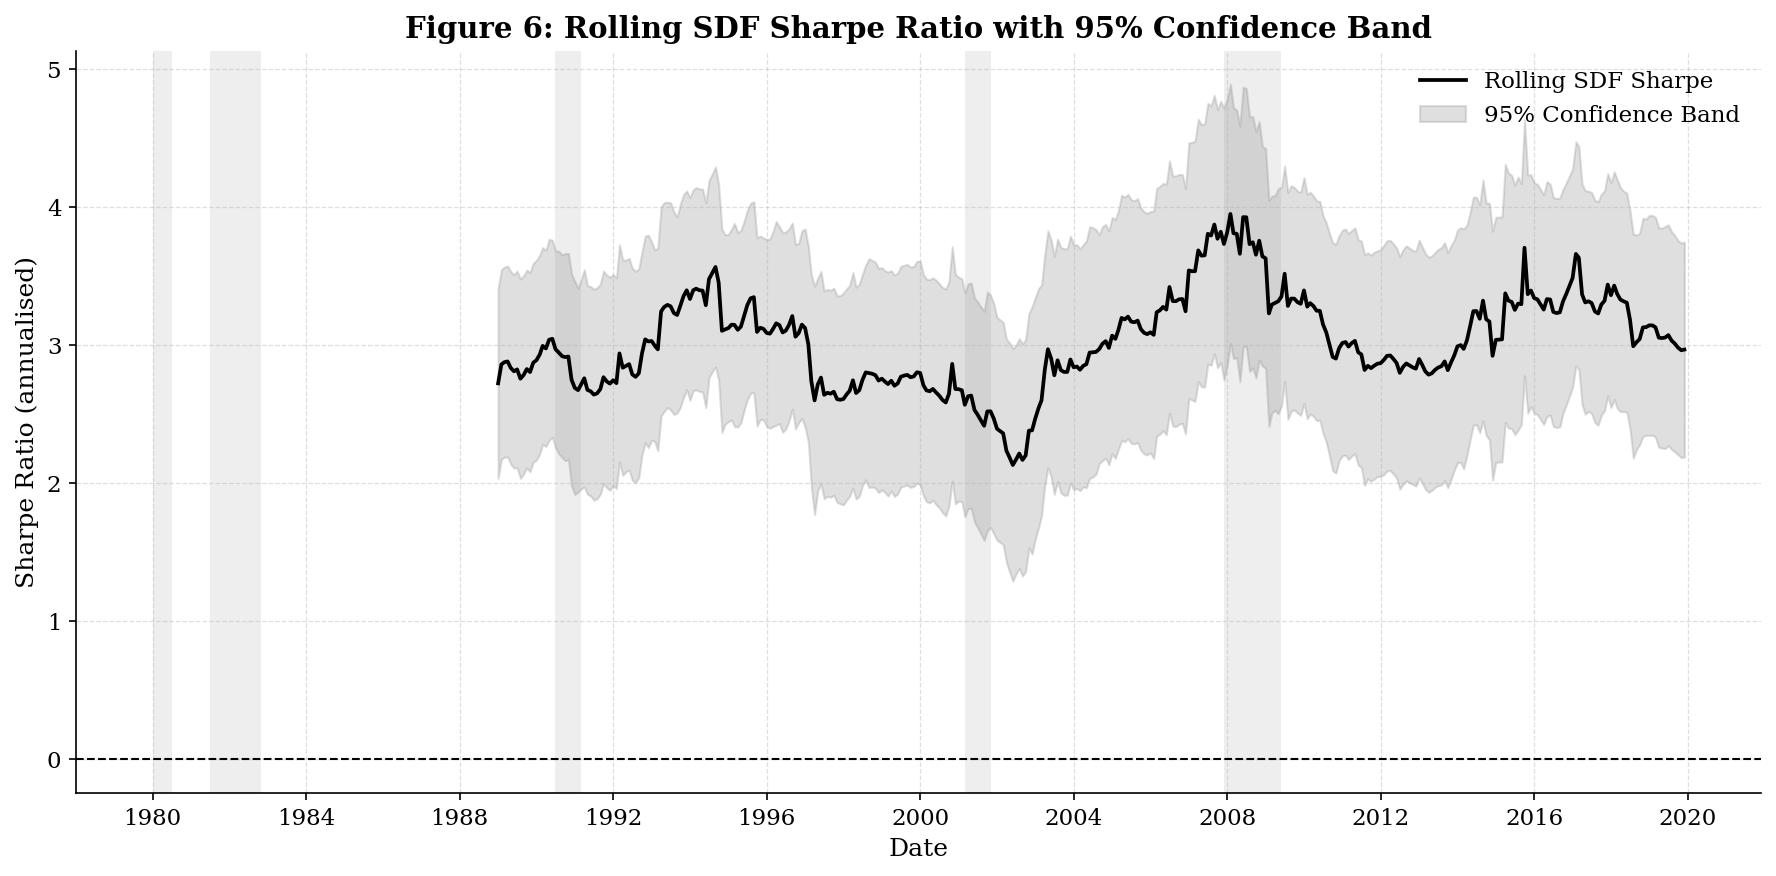

Figure 6 saved.


In [11]:
# Figure 6: Rolling Sharpe with Newey-West 95% CI
sr_df = compute_rolling_sharpe_with_CI(m_series, window=SDF_WINDOW,
                                        freq=12, nw_lag=NW_LAG)

fig6, ax = plt.subplots(figsize=(12, 6))
ax.plot(sr_df.index, sr_df["Sharpe"],
        color="black", linewidth=1.8, label="Rolling SDF Sharpe")
ax.fill_between(sr_df.index, sr_df["CI_lower"], sr_df["CI_upper"],
                color="gray", alpha=0.25, label="95% Confidence Band")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
shade_recessions(ax)
ax.set_ylabel("Sharpe Ratio (annualised)")
ax.set_xlabel("Date")
ax.set_title("Figure 6: Rolling SDF Sharpe Ratio with 95% Confidence Band",
             fontweight="bold")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.legend(frameon=False)

sr_clean = sr_df["Sharpe"].dropna()
print(f"Rolling Sharpe -- mean: {sr_clean.mean():.2f}  "
      f"range: [{sr_clean.min():.2f}, {sr_clean.max():.2f}]")
plt.tight_layout()
save_figure(fig6, "Figure6_Rolling_SDF_Sharpe")
plt.show()
print("Figure 6 saved.")